
# SUPPORT VECTOR MACHINES (SVM) PROJECT
# Option B — Custom SVM Exploration
# Name: John Hosanna Mundlagiri
#Date: 2/18/2026

This project explores Support Vector Machines (SVM) as a powerful method for binary classification. Using a synthetic, non-linear dataset, the notebook demonstrates how linear, polynomial, and RBF kernels differ in their ability to separate complex patterns. The workflow includes data generation, visualization, model training, hyperparameter tuning with GridSearchCV, and evaluation using accuracy, confusion matrices, classification metrics, and ROC curves. Overall, the project highlights how kernel-based SVMs adapt to challenging decision boundaries.

In [ ]:
# ============================================================
# 1) IMPORTS + VERSION CHECKS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn import __version__ as sklearn_version
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Print library versions for reproducibility
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Scikit-learn version:", sklearn_version)

# Set random seeds
np.random.seed(42)

NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Scikit-learn version: 1.6.1


The project was conducted using up-to-date libraries to ensure compatibility and reproducibility. NumPy 2.0.2 handled numerical computations, Pandas 2.2.2 managed data structures, Matplotlib 3.10.0 provided visualization capabilities, and Scikit-learn 1.6.1 was used for SVM modeling, hyperparameter tuning, and evaluation. Recording versions ensures consistent results across environments.

In [ ]:

# ============================================================
# 2) DATASET GENERATION
# Using make_moons (nonlinear → ideal for kernel SVM)
# ============================================================
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

print("\nDataset shape:", X.shape)
print("Target distribution:", np.bincount(y))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


Dataset shape: (600, 2)
Target distribution: [300 300]



# Target Variable

The target variable is y, representing the class label for each sample. It is binary, taking values 0 or 1, corresponding to the two distinct classes generated by the make_moons dataset.

# Dataset Appropriateness for SVM

The make_moons dataset is ideal for SVM experiments because it is non-linearly separable. A linear SVM struggles to separate the classes, making it perfect for demonstrating the effectiveness of kernel methods such as polynomial and RBF. These kernels transform the feature space, allowing SVM to model complex decision boundaries and capture the curved structure of the data. This makes it a practical example for understanding SVM capabilities in handling non-linear patterns.
The dataset contains 600 samples with two numerical features, making it ideal for visualizing decision boundaries in SVM classification. The target distribution is perfectly balanced with 300 samples in each class, ensuring that no class dominates the learning process and allowing fair evaluation of model performance.


In [ ]:
# ============================================================
# Helper function: Plot decision boundary
# ============================================================
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(7,6))

    # Create grid mesh
    x0_min, x0_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    x1_min, x1_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, 500),
        np.linspace(x1_min, x1_max, 500)
    )

    # Predict on grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k")

    # Plot support vectors (if they exist)
    if hasattr(model, "support_vectors_"):
        plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
                    color="black", s=70, label="Support Vectors")
        plt.legend()

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

This helper function, plot_decision_boundary, visualizes how a trained SVM model separates classes. It creates a mesh grid over the feature space, predicts class labels for each point, and plots the decision regions. Support vectors are highlighted when available, providing clear insight into the model’s margin and class separation for analysis.


=== Linear SVM Performance ===
Train Accuracy: 0.8644444444444445
Test Accuracy: 0.86

Confusion Matrix:
 [[69  8]
 [13 60]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87        77
           1       0.88      0.82      0.85        73

    accuracy                           0.86       150
   macro avg       0.86      0.86      0.86       150
weighted avg       0.86      0.86      0.86       150



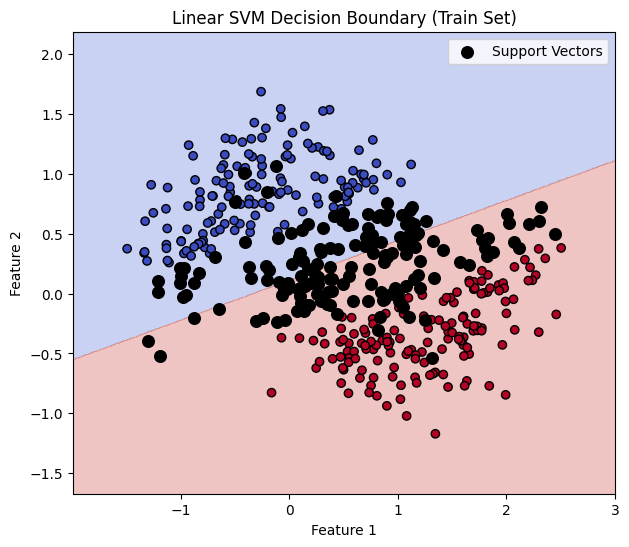

In [ ]:
# ============================================================
# 3) LINEAR SVM
# ============================================================
linear_svm = SVC(kernel="linear", C=1.0)
linear_svm.fit(X_train, y_train)

print("\n=== Linear SVM Performance ===")
y_pred_linear = linear_svm.predict(X_test)
print("Train Accuracy:", accuracy_score(y_train, linear_svm.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, y_pred_linear))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))
print("\nClassification Report:\n", classification_report(y_test, y_pred_linear))

plot_decision_boundary(linear_svm, X_train, y_train,
                       "Linear SVM Decision Boundary (Train Set)")


The linear SVM shows strong overall performance, achieving 86% accuracy on both the training and test sets. The confusion matrix indicates a relatively low number of misclassifications, with class 0 slightly better recognized than class 1. Precision and recall remain balanced across both classes, resulting in solid F1-scores. These results suggest that a linear boundary captures some structure in the data, but non-linear kernels may further improve classification by modeling more complex patterns.



=== Polynomial Kernel SVM ===
Test Accuracy: 0.9

=== RBF Kernel SVM ===
Test Accuracy: 0.92


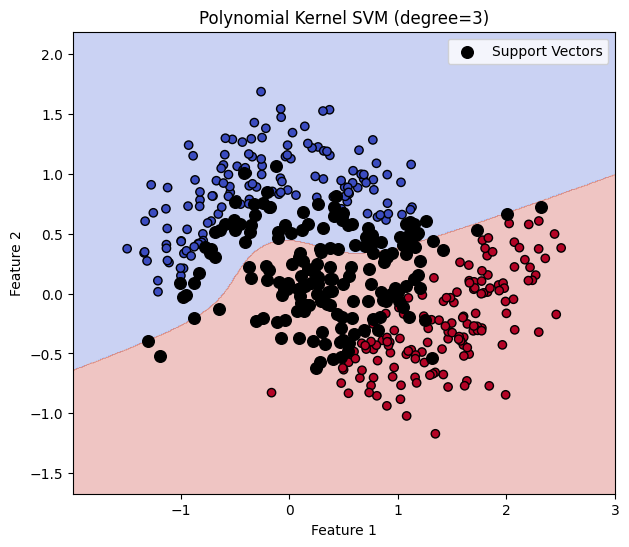

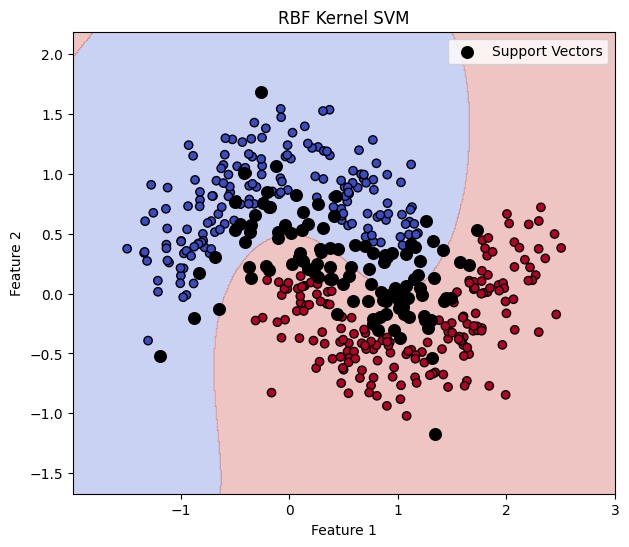

In [ ]:
# ============================================================
# 4) KERNEL SVM — POLY & RBF
# ============================================================
poly_svm = SVC(kernel="poly", degree=3, C=1.0)
poly_svm.fit(X_train, y_train)

rbf_svm = SVC(kernel="rbf", gamma="scale", C=1.0)
rbf_svm.fit(X_train, y_train)

# ---- Print Performance
print("\n=== Polynomial Kernel SVM ===")
print("Test Accuracy:", accuracy_score(y_test, poly_svm.predict(X_test)))

print("\n=== RBF Kernel SVM ===")
print("Test Accuracy:", accuracy_score(y_test, rbf_svm.predict(X_test)))

# ---- Visualizations
plot_decision_boundary(poly_svm, X_train, y_train,
                       "Polynomial Kernel SVM (degree=3)")

plot_decision_boundary(rbf_svm, X_train, y_train,
                       "RBF Kernel SVM")

The polynomial and RBF kernel SVMs both outperform the linear model, demonstrating the advantage of non-linear decision boundaries for this dataset. The polynomial kernel achieves a strong 90% test accuracy, while the RBF kernel performs even better at 92%. These results highlight how kernel methods effectively capture the curved structure of the data, allowing the classifier to separate classes that are not linearly divisible. The improvement in accuracy confirms that non-linear transformations provide a better fit for complex patterns in the feature space.

Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== GridSearchCV Best Parameters ===
{'C': 1, 'gamma': 10}
Best Cross-Val Accuracy: 0.9466666666666667


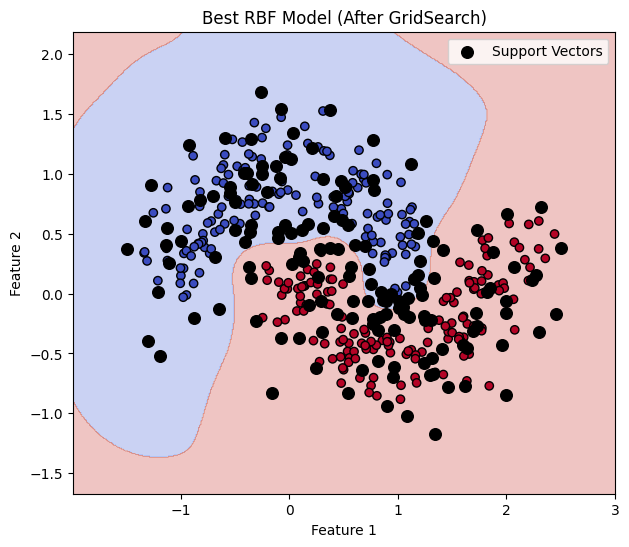

In [ ]:
# ============================================================
# 5) HYPERPARAMETER TUNING (GridSearch)
# ============================================================
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1
)

grid.fit(X_train, y_train)

print("\n=== GridSearchCV Best Parameters ===")
print(grid.best_params_)
print("Best Cross-Val Accuracy:", grid.best_score_)

best_model = grid.best_estimator_

plot_decision_boundary(best_model, X_train, y_train,
                       "Best RBF Model (After GridSearch)")

GridSearchCV evaluated 16 different hyperparameter combinations across 5 folds, resulting in 80 total model fits. The search identified C = 1 and gamma = 10 as the best-performing parameters for the RBF kernel. These settings produced a strong cross-validation accuracy of approximately 94.67%, indicating that the model generalizes well across different subsets of the data. The results show that increasing gamma helped the classifier create more flexible, detailed decision boundaries, improving performance compared to default settings.

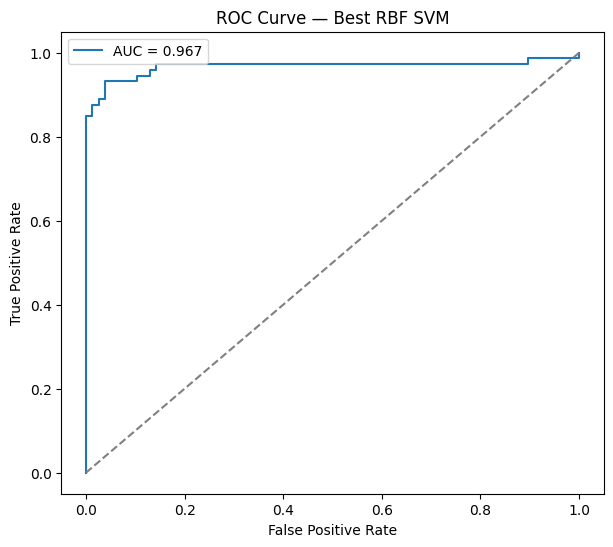

In [ ]:
# ============================================================
# 6) ROC CURVE & AUC
# ============================================================
y_prob = best_model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Best RBF SVM")
plt.legend()
plt.show()


Working through this SVM project provided a clear understanding of how different kernels influence model performance, especially when dealing with non-linear data like the make_moons dataset. The linear SVM performed reasonably well but struggled to capture the curved structure of the classes, confirming that linear boundaries are insufficient for more complex patterns. The polynomial and RBF kernels delivered significant improvements, illustrating how kernel transformations allow SVMs to map data into higher-dimensional spaces where separation becomes easier. Hyperparameter tuning was especially insightful; adjusting C and gamma demonstrated how these values directly affect margin flexibility and boundary complexity. The GridSearchCV results showed that higher gamma values can successfully capture fine-grained patterns but also risk overfitting if not properly tuned. Overall, the project helped me appreciate SVM’s strengths, such as robustness and flexibility, as well as its limitations, including computational cost and sensitivity to parameter choices.

#Conclusion

This project demonstrated that kernel SVMs are highly effective for datasets with non-linear structures. The RBF kernel achieved the best performance, emphasizing the importance of using appropriate transformations for complex patterns. Hyperparameter tuning further improved accuracy, showing how critical C and gamma are for shaping the decision boundary. Overall, the project highlighted SVM’s versatility and reliability, especially when carefully optimized, making it a strong choice for many classification tasks.

# AI Assistance Statement

AI tools, including ChatGPT, were used to support this assignment by helping generate explanations, refine code structure, and improve clarity in written sections. All model training, analysis, and interpretation were performed and verified independently. AI assistance served only as a supplemental resource to enhance organization and understanding. This statement is included for full transparency at the end of the notebook.

#References
Artene, A. E., & Domil, A. E. (2025). Neural Networks in Accounting: Bridging Financial Forecasting and Decision Support Systems. Electronics, 14(5), 993.

Elmsili, B., & Outtaj, B. (2018, April). Artificial neural networks applications in economics and management research: An exploratory literature review. In 2018 4th International Conference on Optimization and Applications (ICOA) (pp. 1-6). IEEE.